In [1]:
import pandas as pd

products = pd.read_csv("../ecommerce_dataset/products.csv")
customers = pd.read_csv("../ecommerce_dataset/users.csv")
orders = pd.read_csv("../ecommerce_dataset/orders.csv")
order_items = pd.read_csv("../ecommerce_dataset/order_items.csv")
reviews = pd.read_csv("../ecommerce_dataset/reviews.csv")
events = pd.read_csv("../ecommerce_dataset/events.csv")

In [2]:
print(f"Number of Products: {products.shape[0]}")
print(f"Number of Features: {products.shape[1]}")

products.head()

Number of Products: 2000
Number of Features: 6


,product_id,product_name,category,brand,price,rating
0,P000001,Astra Be,Clothing,Astra,157.89,4.08
1,P000002,NeoTech Someone,Groceries,NeoTech,21.46,3.87
2,P000003,Acme Discuss,Sports,Acme,265.37,3.46
3,P000004,Nimbus South,Electronics,Nimbus,541.41,4.14
4,P000005,Astra Capital,Home & Kitchen,Astra,198.00,3.97


In [3]:
products.describe(include='all')

,product_id,product_name,category,brand,price,rating
count,2000,2000,2000,2000,2000.000000,2000.000000
unique,2000,1848,10,12,NaN,NaN
top,P000001,Nimbus Word,Clothing,Zenith,NaN,NaN
freq,1,3,213,190,NaN,NaN
mean,NaN,NaN,NaN,NaN,200.342230,3.677615
std,NaN,NaN,NaN,NaN,302.742395,0.686478
min,NaN,NaN,NaN,NaN,1.110000,2.500000
25%,NaN,NaN,NaN,NaN,36.335000,3.070000
50%,NaN,NaN,NaN,NaN,84.220000,3.690000
75%,NaN,NaN,NaN,NaN,210.817500,4.250000


In [4]:
products.columns

Index(['product_id', 'product_name', 'category', 'brand', 'price', 'rating'], dtype='object')

In [5]:
print(f"Number of Products: {products.shape[0]}")
products["category"].nunique()
products["category"].value_counts()
products["brand"].nunique()
products["brand"].value_counts().head(10)

Number of Products: 2000


brand
Zenith       190
Harbor       183
Nimbus       182
GreenLeaf    174
Astra        165
Willow       165
NeoTech      163
Orion        163
Everest      157
Solace       156
Name: count, dtype: int64

In [6]:
products["price"].describe()

count    2000.000000
mean      200.342230
std       302.742395
min         1.110000
25%        36.335000
50%        84.220000
75%       210.817500
max      2338.130000
Name: price, dtype: float64

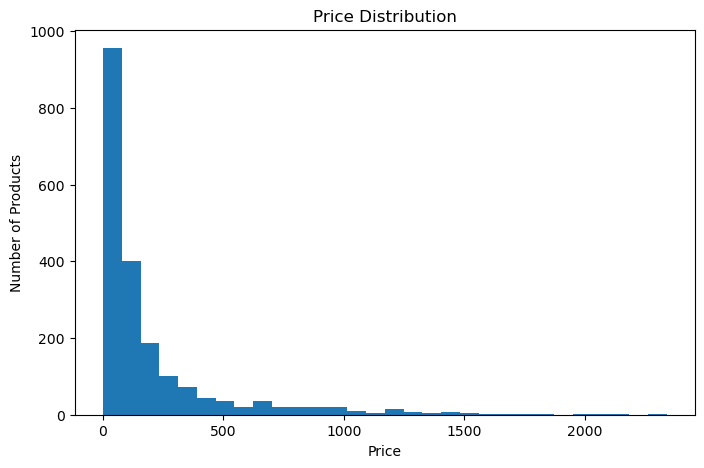

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(products["price"], bins=30)

plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Number of Products")

plt.show()

In [8]:
products.sort_values("price", ascending=False).head(10)

,product_id,product_name,category,brand,price,rating
1023,P001024,Astra Pull,Electronics,Astra,2338.13,3.47
909,P000910,Orion Group,Electronics,Orion,2337.85,3.44
135,P000136,Zenith Phone,Electronics,Zenith,2169.98,4.38
1526,P001527,Willow Result,Electronics,Willow,2035.42,3.87
1374,P001375,Astra Owner,Electronics,Astra,1993.95,2.52
1182,P001183,Nimbus Word,Electronics,Nimbus,1835.32,3.51
641,P000642,Acme Group,Electronics,Acme,1816.28,3.65
1743,P001744,Acme Artist,Electronics,Acme,1797.55,3.21
20,P000021,Willow Special,Electronics,Willow,1772.36,2.90
680,P000681,Acme Keep,Electronics,Acme,1708.20,2.93


In [9]:
products.sort_values("price").head(10)

,product_id,product_name,category,brand,price,rating
692,P000693,GreenLeaf Job,Groceries,GreenLeaf,1.11,2.84
1583,P001584,NeoTech Rich,Groceries,NeoTech,1.21,4.18
1544,P001545,NeoTech Everyone,Groceries,NeoTech,1.49,2.94
1178,P001179,Astra Player,Groceries,Astra,1.72,2.60
1081,P001082,Orion Night,Groceries,Orion,1.78,3.12
1753,P001754,Zenith Something,Groceries,Zenith,1.78,2.68
1914,P001915,Solace Or,Groceries,Solace,2.41,2.99
1708,P001709,Nimbus Unit,Groceries,Nimbus,2.47,3.14
1217,P001218,NeoTech Food,Groceries,NeoTech,2.48,2.90
750,P000751,Willow At,Books,Willow,2.72,3.47


In [10]:
products["rating"].describe()

count    2000.000000
mean        3.677615
std         0.686478
min         2.500000
25%         3.070000
50%         3.690000
75%         4.250000
max         4.900000
Name: rating, dtype: float64

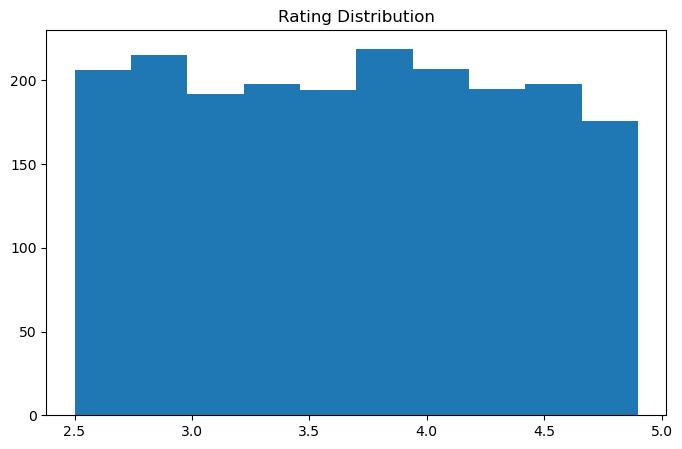

In [11]:
plt.figure(figsize=(8,5))

plt.hist(products["rating"], bins=10)

plt.title("Rating Distribution")

plt.show()

Customers

In [12]:
customers.columns

Index(['user_id', 'name', 'email', 'gender', 'city', 'signup_date'], dtype='object')

In [13]:
customers["gender"].value_counts()

gender
Other     3419
Female    3334
Male      3247
Name: count, dtype: int64

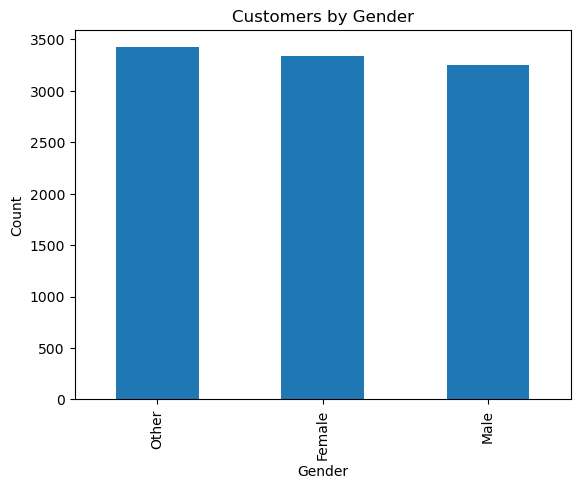

In [14]:
import matplotlib.pyplot as plt

customers["gender"].value_counts().plot(kind="bar")

plt.title("Customers by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

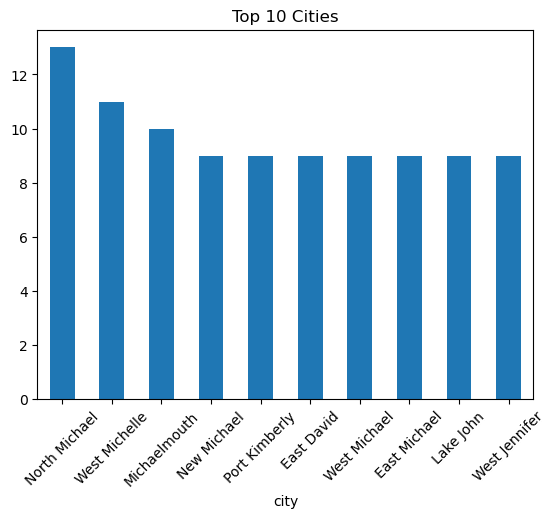

In [15]:
customers["city"].value_counts().head(10)
customers["city"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Cities")
plt.xticks(rotation=45)

plt.show()

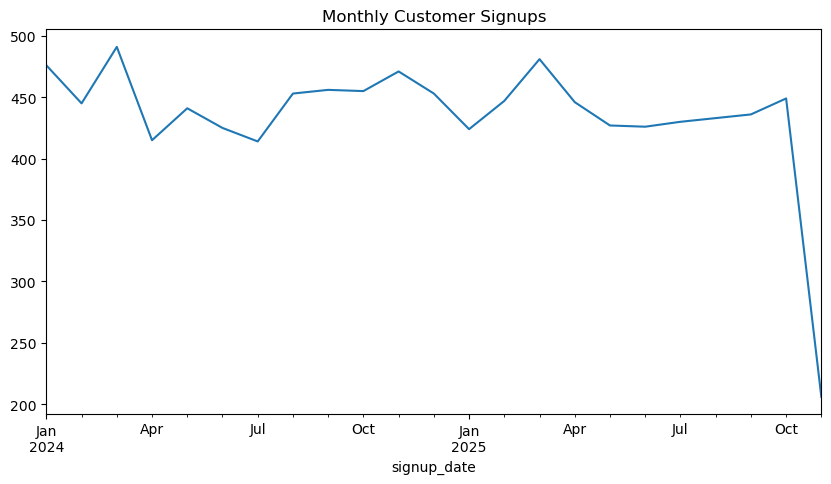

In [17]:
customers["signup_date"] = pd.to_datetime(customers["signup_date"])
customers["signup_date"].dt.to_period("M").value_counts().sort_index()
customers["signup_date"]\
    .dt.to_period("M")\
    .value_counts()\
    .sort_index()\
    .plot(figsize=(10,5))

plt.title("Monthly Customer Signups")

plt.show()

Reviews


In [18]:
reviews.columns

Index(['review_id', 'order_id', 'product_id', 'user_id', 'rating',
       'review_text', 'review_date'],
      dtype='object')

In [19]:
print(f"Average Rating: {reviews['rating'].mean():.2f}")

Average Rating: 3.54


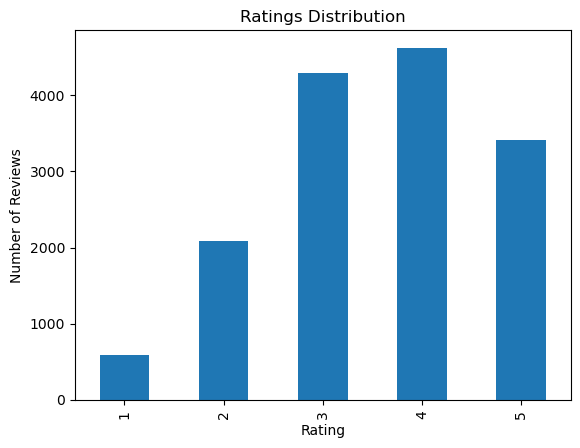

In [20]:
reviews["rating"].value_counts().sort_index()
reviews["rating"].value_counts().sort_index().plot(kind="bar")

plt.title("Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

plt.show()

In [21]:
reviews.groupby("product_id")["rating"] \
       .mean() \
       .sort_values(ascending=False) \
       .head(10)

product_id
P000773    5.000000
P001986    5.000000
P000844    5.000000
P000833    5.000000
P000275    5.000000
P000904    5.000000
P001074    4.750000
P001931    4.750000
P001455    4.666667
P000060    4.666667
Name: rating, dtype: float64

In [22]:
reviews.groupby("product_id")["rating"] \
       .mean() \
       .sort_values() \
       .head(10)

product_id
P001634    2.000000
P001271    2.000000
P001016    2.000000
P000974    2.000000
P001183    2.166667
P001368    2.250000
P000267    2.333333
P001619    2.333333
P001449    2.333333
P000214    2.333333
Name: rating, dtype: float64

In [23]:
orders.columns

Index(['order_id', 'user_id', 'order_date', 'order_status', 'total_amount'], dtype='object')

In [24]:
order_items.columns

Index(['order_item_id', 'order_id', 'product_id', 'user_id', 'quantity',
       'item_price', 'item_total'],
      dtype='object')

In [25]:
events.columns

Index(['event_id', 'user_id', 'product_id', 'event_type', 'event_timestamp'], dtype='object')

Order.Products


In [26]:
order_products = order_items.merge(
    products,
    on="product_id",
    how="left"
)

order_products.head()

,order_item_id,order_id,product_id,user_id,quantity,item_price,item_total,product_name,category,brand,price,rating
0,I00000001,O00000001,P001758,U009310,2,8.07,16.14,Everest Whole,Pet Supplies,Everest,8.07,2.69
1,I00000002,O00000001,P001119,U009310,1,74.08,74.08,Nimbus Minute,Beauty,Nimbus,74.08,3.62
2,I00000003,O00000001,P001794,U009310,1,576.97,576.97,Willow Treatment,Automotive,Willow,576.97,3.89
3,I00000004,O00000001,P001038,U009310,1,22.47,22.47,Nimbus Deal,Books,Nimbus,22.47,4.85
4,I00000005,O00000002,P000859,U003247,1,422.22,422.22,Pulse Decide,Electronics,Pulse,422.22,3.51


In [27]:
top_products = (
    order_products
    .groupby("product_name")["quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

product_name
Solace Particular    104
Orion Coach          101
Everest Beautiful     99
Pulse Money           98
Nimbus Word           97
Harbor Much           96
GreenLeaf Save        91
Zenith Might          88
Nimbus Seven          88
Everest Response      88
Name: quantity, dtype: int64

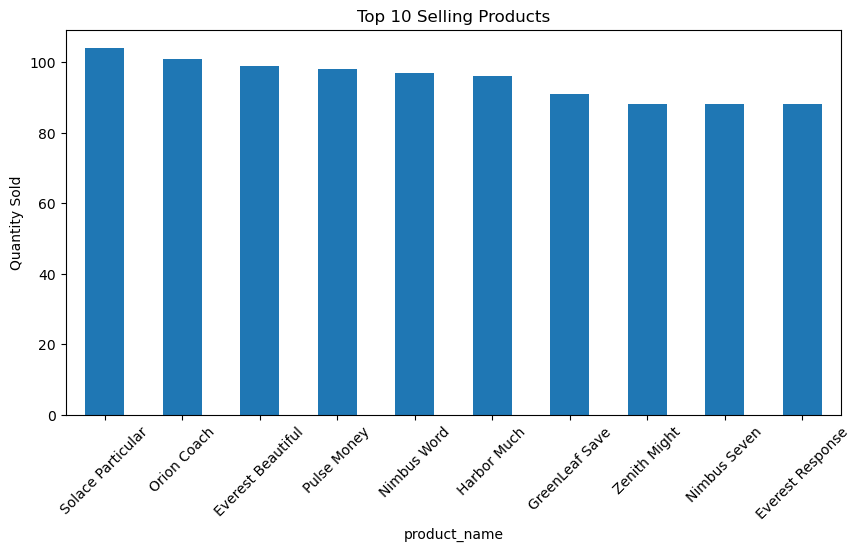

In [28]:
top_products.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Selling Products")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)

plt.show()

In [29]:
bottom_products = (
    order_products
    .groupby("product_name")["quantity"]
    .sum()
    .sort_values()
    .head(10)
)

bottom_products

product_name
Acme Up                 12
NeoTech Better          12
Harbor Improve          12
Nimbus Nature           13
Harbor Group            13
Astra Work              14
Harbor Look             14
Acme Best               14
Orion Administration    14
Astra Behavior          15
Name: quantity, dtype: int64

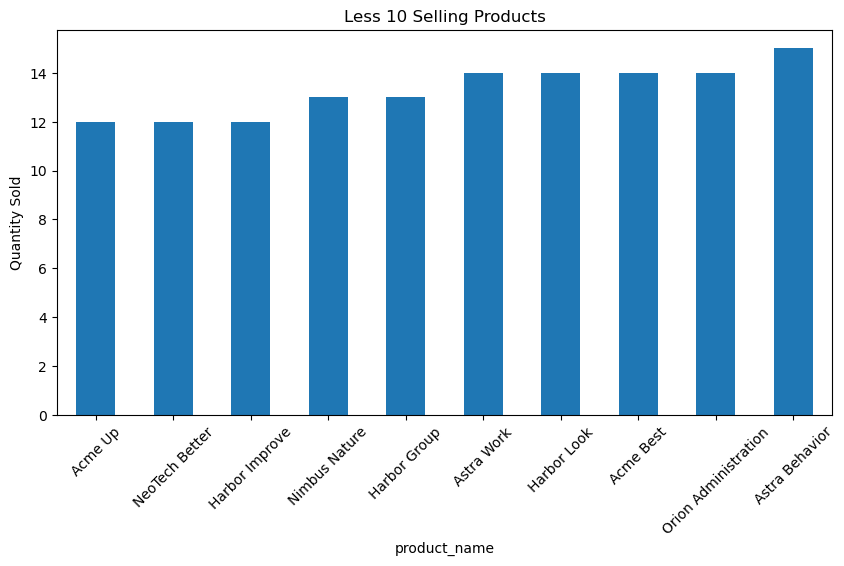

In [31]:
bottom_products.plot(kind="bar", figsize=(10,5))

plt.title("Less 10 Selling Products")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)

plt.show()

In [32]:
category_sales = (
    order_products
    .groupby("category")["item_total"]
    .sum()
    .sort_values(ascending=False)
)

category_sales

category
Electronics       4961736.60
Automotive        2501360.55
Home & Kitchen    1132697.25
Sports             952403.23
Clothing           710953.62
Beauty             555775.00
Toys               385482.77
Pet Supplies       354035.82
Books              274825.95
Groceries           89398.16
Name: item_total, dtype: float64

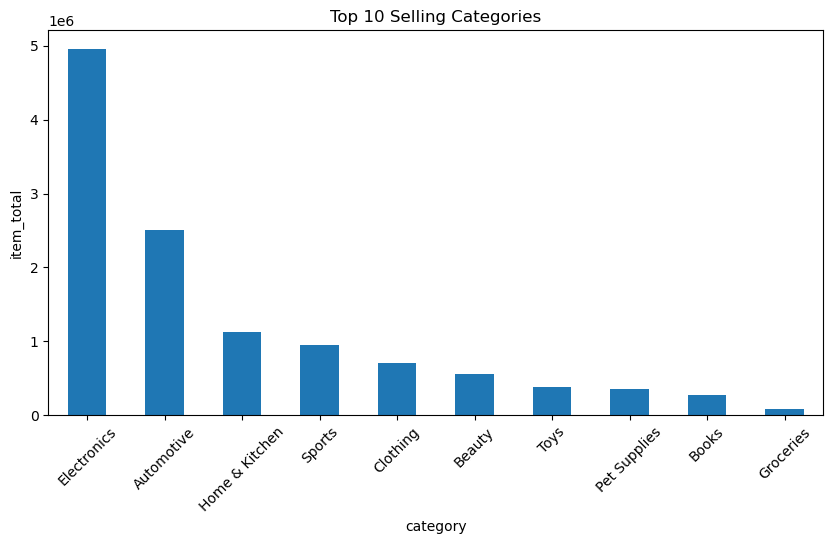

In [34]:
category_sales.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Selling Categories")
plt.ylabel("item_total")
plt.xticks(rotation=45)

plt.show()

In [35]:
brand_sales = (
    order_products
    .groupby("brand")["item_total"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

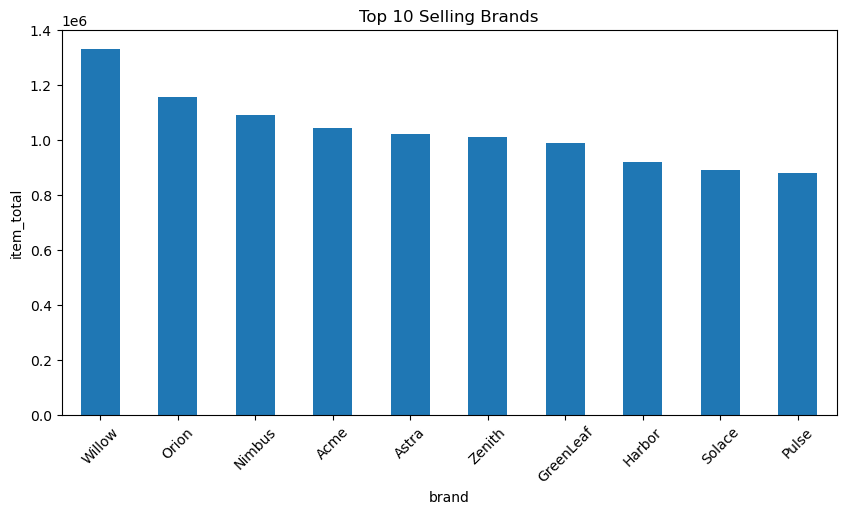

In [36]:
brand_sales.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Selling Brands")
plt.ylabel("item_total")
plt.xticks(rotation=45)

plt.show()

In [37]:
orders["total_amount"].mean()

np.float64(595.9334474999999)

Orders   

In [38]:
sales = orders.merge(
    order_items,
    on=["order_id", "user_id"],
    how="inner"
)

sales.head()

,order_id,user_id,order_date,order_status,total_amount,order_item_id,product_id,quantity,item_price,item_total
0,O00000001,U009310,2025-09-09T14:52:37.292731,processing,689.66,I00000001,P001758,2,8.07,16.14
1,O00000001,U009310,2025-09-09T14:52:37.292731,processing,689.66,I00000002,P001119,1,74.08,74.08
2,O00000001,U009310,2025-09-09T14:52:37.292731,processing,689.66,I00000003,P001794,1,576.97,576.97
3,O00000001,U009310,2025-09-09T14:52:37.292731,processing,689.66,I00000004,P001038,1,22.47,22.47
4,O00000002,U003247,2025-04-15T01:18:27.193404,completed,1666.85,I00000005,P000859,1,422.22,422.22


In [39]:
sales["order_date"] = pd.to_datetime(sales["order_date"])

In [40]:
monthly_sales = (
    sales
    .groupby(sales["order_date"].dt.to_period("M"))["item_total"]
    .sum()
)

monthly_sales

order_date
2024-01    543120.43
2024-02    513712.79
2024-03    541213.26
2024-04    545624.46
2024-05    552700.82
2024-06    548534.32
2024-07    587135.76
2024-08    519474.77
2024-09    529067.12
2024-10    529215.48
2024-11    511353.41
2024-12    566301.67
2025-01    502918.44
2025-02    460378.18
2025-03    505664.69
2025-04    531844.95
2025-05    538676.95
2025-06    507913.96
2025-07    550200.98
2025-08    511865.24
2025-09    522376.37
2025-10    521334.46
2025-11    278040.44
Freq: M, Name: item_total, dtype: float64

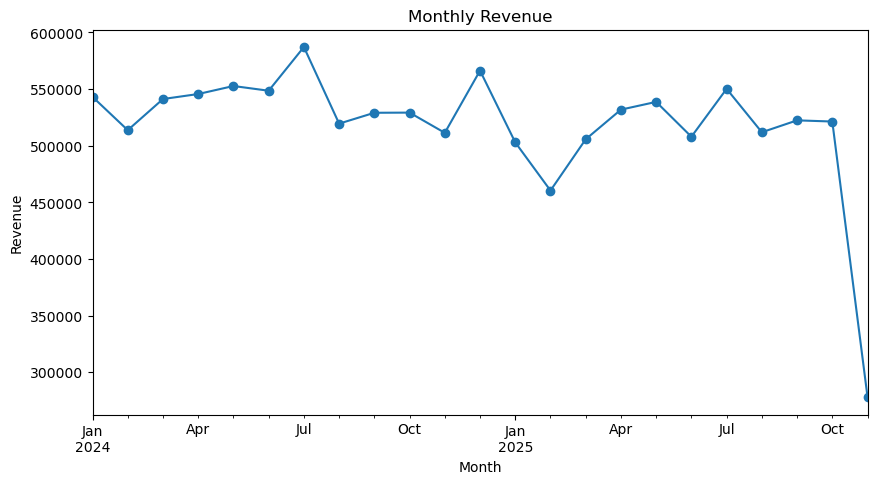

In [41]:
monthly_sales.plot(figsize=(10,5), marker="o")

plt.title("Monthly Revenue")
plt.ylabel("Revenue")
plt.xlabel("Month")

plt.show()

Top Customers

In [43]:
top_customers = (
    sales
    .groupby("user_id")["item_total"]
    .sum()
    .reset_index()
)

top_customers = top_customers.merge(
    customers,
    on="user_id"
)

top_customers.sort_values(
    "item_total",
    ascending=False
).head(10)

,user_id,item_total,name,email,gender,city,signup_date
8571,U009931,13288.88,Meagan Case,davidjohnson@example.org,Female,Lake Alyssamouth,2024-12-01
5374,U006233,11234.22,Willie Esparza,jay63@example.com,Male,Tylerland,2025-06-19
5572,U006469,10953.18,Audrey Ware,gibsonedward@example.net,Female,South Robertstad,2024-03-12
7222,U008370,10190.11,Brittany Carrillo,shaneblack@example.org,Other,Bryanport,2025-10-14
4918,U005702,10175.81,Shawn Greene,perrybarbara@example.net,Female,New Ashleebury,2025-03-01
8549,U009903,10118.31,Jessica Russell,elizabeth33@example.net,Female,Nolanborough,2025-07-31
5,U000006,9952.28,Michael Santiago,lynchgeorge@example.net,Male,East Steven,2024-04-21
4238,U004906,9538.69,Brenda Winters,meyervalerie@example.org,Other,East Emilyview,2024-06-21
5372,U006231,9486.29,Jerome Warner,katie76@example.org,Other,Port Katherineview,2025-11-14
6834,U007930,8947.98,Robert Jennings,floresamanda@example.net,Male,Port James,2025-09-01


In [44]:
order_items.groupby("order_id")["quantity"].sum().mean()

np.float64(3.0409)

Top Customers
Meagan Case        U009931
Willie Esparza     U006233
Audrey Ware        U006469	
Brittany Carrillo  U008370	
Shawn Greene       U005702
Jessica Russell    U009903
Michael Santiago   U000006	
Brenda Winters     U004906	
Jerome Warner      U006231
Robert Jennings	   U007930

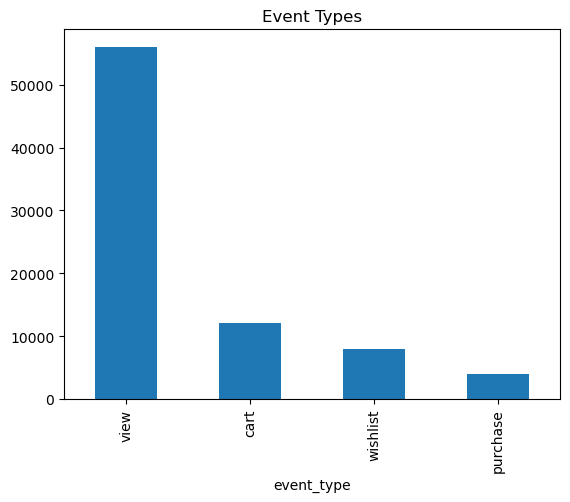

In [45]:
events["event_type"].value_counts()
events["event_type"].value_counts().plot(kind="bar")

plt.title("Event Types")

plt.show()

In [46]:
views = len(events[events["event_type"]=="view"])

cart = len(events[events["event_type"]=="cart"])

purchase = len(events[events["event_type"]=="purchase"])
print("View -> Cart:", cart/views)

print("Cart -> Purchase:", purchase/cart)

View -> Cart: 0.2148608358773856
Cart -> Purchase: 0.33286248442044036


In [ ]:
views = events[events["event_type"]=="view"]

top_views = (
    views
    .groupby("product_id")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

In [49]:
view_events = events[events["event_type"] == "view"]

top_views = (
    view_events
    .groupby("product_id")
    .size()
    .reset_index(name="views")
)

top_views = top_views.merge(
    products,
    on="product_id",
    how="left"
)

top_views.sort_values("views", ascending=False).head(10)

,product_id,views,product_name,category,brand,price,rating
515,P000516,46,Nimbus Threat,Sports,Nimbus,253.68,4.64
1434,P001435,42,Harbor Eye,Books,Harbor,36.92,4.58
607,P000608,42,GreenLeaf Visit,Toys,GreenLeaf,42.74,4.89
1770,P001771,42,GreenLeaf Guess,Sports,GreenLeaf,120.32,4.36
1941,P001942,42,Everest School,Toys,Everest,24.99,3.77
100,P000101,42,Willow Cultural,Clothing,Willow,32.69,2.69
1831,P001832,42,Orion Medical,Home & Kitchen,Orion,52.77,4.16
1192,P001193,42,Zenith Team,Pet Supplies,Zenith,26.76,4.08
1383,P001384,41,Pulse Few,Clothing,Pulse,15.03,4.77
49,P000050,41,Everest Easy,Clothing,Everest,108.18,4.17


In [50]:
purchase_events = events[events["event_type"]=="purchase"]
top_purchase = (
    purchase_events
    .groupby("product_id")
    .size()
    .reset_index(name="purchases")
)

top_purchase = top_purchase.merge(
    products,
    on="product_id",
    how="left"
)

top_purchase.sort_values("purchases", ascending=False).head(10)

,product_id,purchases,product_name,category,brand,price,rating
944,P001113,8,Pulse Interesting,Electronics,Pulse,1663.12,3.86
837,P000984,8,Pulse Possible,Home & Kitchen,Pulse,244.36,3.13
389,P000454,7,Solace Different,Home & Kitchen,Solace,231.49,3.58
1058,P001235,7,Everest Manage,Groceries,Everest,11.40,4.28
436,P000510,7,Zenith Guy,Sports,Zenith,105.34,2.87
858,P001011,7,Astra Many,Pet Supplies,Astra,48.22,4.42
216,P000258,7,Orion Trouble,Groceries,Orion,11.34,4.46
0,P000001,6,Astra Be,Clothing,Astra,157.89,4.08
184,P000216,6,Pulse Serious,Sports,Pulse,295.05,4.86
196,P000234,6,NeoTech Fear,Electronics,NeoTech,375.37,3.59


Business Insights